# Seasonal Statistical Forecasting

Phase 3B evaluates one Dynamic Harmonic Regression benchmark with daily and weekly Fourier terms and low-order non-seasonal ARIMA errors. It does not alter frozen deterministic artifacts.


## 1. Load Frozen Electricity Data


In [1]:
from pathlib import Path
import sys,time,warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/")

ROOT=find_project_root(Path.cwd()); RESULTS=ROOT/"results/electricity"; DATA=ROOT/"data/electricity/australian_electricity_demand_dataset.tsf"
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from src.metrics import mae,rmse,mape,smape

def load_tsf(path):
    attrs=[]; rows=[]
    with Path(path).open(encoding="utf-8") as f:
        for raw in f:
            line=raw.strip()
            if not line or line.startswith("#"): continue
            if line.startswith("@attribute"):
                _,n,k=line.split(maxsplit=2); attrs.append((n,k))
            elif not line.startswith("@"):
                p=line.split(":",len(attrs)); r=dict(zip((a[0] for a in attrs),p[:-1])); r["series_value"]=np.fromstring(p[-1],sep=","); rows.append(r)
    return pd.DataFrame(rows)
raw=load_tsf(DATA); row=raw[(raw.series_name=="T4")&(raw.state=="SA")].iloc[0]
idx=pd.date_range(pd.to_datetime(row.start_timestamp,format="%Y-%m-%d %H-%M-%S"),periods=len(row.series_value),freq="30min")
y=pd.Series(row.series_value,index=idx,name="Demand")
assert row.series_name=="T4" and row.state=="SA" and len(y)==230784 and pd.infer_freq(y.index)=="30min"
print("Loaded",row.series_name,row.state,len(y),y.index.min(),y.index.max())


Loaded T4 SA 230784 2002-01-01 00:00:00 2015-03-01 23:30:00


## 2. Frozen Partitions


In [2]:
dev=y.loc[:"2011-06-23 23:30"]; val=y.loc["2011-06-24":"2012-07-12 23:30"]; pre=y.loc[:"2012-07-12 23:30"]; test=y.loc["2012-07-13":]
assert (len(dev),len(val),len(pre),len(test))==(166128,18480,184608,46176)
scale_dev=np.mean(np.abs(dev.to_numpy()[48:]-dev.to_numpy()[:-48])); scale_final=np.mean(np.abs(pre.to_numpy()[48:]-pre.to_numpy()[:-48]))
display(pd.DataFrame({"Partition":["Development","Validation","Pre-test","Test"],"Start":[z.index[0] for z in [dev,val,pre,test]],"End":[z.index[-1] for z in [dev,val,pre,test]],"N":[len(z) for z in [dev,val,pre,test]]}))
print("MASE-48 denominators",scale_dev,scale_final)


,Partition,Start,End,N
0,Development,2002-01-01,2011-06-23 23:30:00,166128
1,Validation,2011-06-24,2012-07-12 23:30:00,18480
2,Pre-test,2002-01-01,2012-07-12 23:30:00,184608
3,Test,2012-07-13,2015-03-01 23:30:00,46176


MASE-48 denominators 117.73422807843208 117.05797128067839


## 3. Why Dynamic Harmonic Regression

A conventional seasonal ARIMA with simultaneous periods 48 and 336 would create an unnecessarily large state space over more than 166,000 development observations. This implementation uses deterministic Fourier regression for both seasonalities, followed by a separately estimated low-order ARIMA residual process. This is the protocol-permitted computational fallback: parameters are fixed after fitting, while observed residual states are updated sequentially. No seasonal ARIMA order is used.


## 4. Fourier Feature Construction


In [3]:
PERIODS=(48,336); DAILY_GRID=[2,4,6]; WEEKLY_GRID=[2,4,6]; ORDER_GRID=[(1,0,0),(2,0,0),(1,0,1)]
def fourier(t,kd,kw):
    t=np.asarray(t,float); cols=[np.ones(len(t))]
    for period,K in [(48,kd),(336,kw)]:
        for k in range(1,K+1): cols.extend([np.sin(2*np.pi*k*t/period),np.cos(2*np.pi*k*t/period)])
    return np.column_stack(cols)
for kd in DAILY_GRID:
    for kw in WEEKLY_GRID: assert fourier(np.arange(10),kd,kw).shape==(10,1+2*kd+2*kw)
print("Periods",PERIODS,"daily grid",DAILY_GRID,"weekly grid",WEEKLY_GRID,"orders",ORDER_GRID)


Periods (48, 336) daily grid [2, 4, 6] weekly grid [2, 4, 6] orders [(1, 0, 0), (2, 0, 0), (1, 0, 1)]


## 5. Validation-Only Model Selection


In [4]:
def fit_fourier(values,start_t,kd,kw):
    X=fourier(np.arange(start_t,start_t+len(values)),kd,kw); beta=np.linalg.lstsq(X,values,rcond=None)[0]; return beta,values-X@beta
def fit_error(resid,order):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore"); fit=ARIMA(resid,order=order,trend="n",enforce_stationarity=False,enforce_invertibility=False).fit(method_kwargs={"maxiter":100})
    p=order[0]; ar=np.asarray(fit.arparams); ma=np.asarray(fit.maparams); return ar,ma,fit
def sequential_error_forecast(resid_history,actual_resid,ar,ma,update=True):
    r=list(np.asarray(resid_history,float)[-max(2,len(ar)):]); innovations=[0.0]
    preds=[]
    for obs in np.asarray(actual_resid,float):
        pred=sum(ar[i]*r[-i-1] for i in range(len(ar))) + (ma[0]*innovations[-1] if len(ma) else 0.0)
        preds.append(pred)
        if update:
            innovations.append(obs-pred); r.append(obs)
        else:
            innovations.append(0.0); r.append(pred)
    return np.asarray(preds)
def metrics(actual,pred,scale): return {"MAE":mae(actual,pred),"RMSE":rmse(actual,pred),"sMAPE":smape(actual,pred),"MASE_48":mae(actual,pred)/scale}

selection_start=time.perf_counter(); rows=[]; cache={}; ndev=len(dev)
for kd in DAILY_GRID:
    for kw in WEEKLY_GRID:
        beta,resid=fit_fourier(dev.to_numpy(),0,kd,kw); mean_val=fourier(np.arange(ndev,ndev+len(val)),kd,kw)@beta; actual_resid=val.to_numpy()-mean_val
        for order in ORDER_GRID:
            ar,ma,fit=fit_error(resid,order); rp=sequential_error_forecast(resid,actual_resid,ar,ma,True); pred=mean_val+rp
            rows.append({"Daily_K":kd,"Weekly_K":kw,"ARIMA_Order":str(order),**metrics(val,pred,scale_dev),"AIC":fit.aic})
selection_runtime=time.perf_counter()-selection_start
selection=pd.DataFrame(rows).sort_values(["MASE_48","RMSE"]).reset_index(drop=True); display(selection)
best=selection.iloc[0]; KD=int(best.Daily_K); KW=int(best.Weekly_K); ORDER=eval(best.ARIMA_Order)
print("SELECTED",KD,KW,ORDER,"selection runtime seconds",selection_runtime)


,Daily_K,Weekly_K,ARIMA_Order,MAE,RMSE,sMAPE,MASE_48,AIC
0,2,6,"(2, 0, 0)",23.799455,44.865557,1.817962,0.202146,1.649868e+06
1,2,4,"(2, 0, 0)",23.849934,44.954711,1.823518,0.202574,1.650485e+06
2,2,2,"(2, 0, 0)",23.855279,44.963552,1.824459,0.202620,1.650548e+06
3,6,6,"(2, 0, 0)",24.579493,41.651370,1.891915,0.208771,1.622153e+06
4,6,4,"(2, 0, 0)",24.660593,41.785031,1.902381,0.209460,1.623202e+06
5,6,2,"(2, 0, 0)",24.664330,41.795798,1.903132,0.209492,1.623284e+06
6,4,6,"(2, 0, 0)",24.673153,42.807849,1.922511,0.209567,1.633009e+06
7,4,2,"(2, 0, 0)",24.731910,42.935997,1.930139,0.210066,1.633975e+06
8,4,4,"(2, 0, 0)",24.732743,42.925991,1.929865,0.210073,1.633901e+06
9,6,6,"(1, 0, 1)",26.287215,41.657817,2.030446,0.223276,1.634448e+06


SELECTED 2 6 (2, 0, 0) selection runtime seconds 484.9734625000001


## 6. Final Model Specification


In [5]:
fit_start=time.perf_counter(); beta,resid_pre=fit_fourier(pre.to_numpy(),0,KD,KW); ar,ma,final_fit=fit_error(resid_pre,ORDER); fit_runtime=time.perf_counter()-fit_start
print({"daily_K":KD,"weekly_K":KW,"order":ORDER,"parameters_fixed_during_test":True,"state_updated_with_observed_residuals":True,"refits_during_test":0,"final_fit_seconds":fit_runtime,"AR":ar.tolist(),"MA":ma.tolist(),"AIC":final_fit.aic})


{'daily_K': 2, 'weekly_K': 6, 'order': (2, 0, 0), 'parameters_fixed_during_test': True, 'state_updated_with_observed_residuals': True, 'refits_during_test': 0, 'final_fit_seconds': 19.123553299999912, 'AR': [1.5164973012271052, -0.5479963028208754], 'MA': [], 'AIC': np.float64(1845275.8064881451)}


## 7. Protocol A Evaluation


In [6]:
t_test=np.arange(len(pre),len(y)); mean_test=fourier(t_test,KD,KW)@beta; actual_resid_test=test.to_numpy()-mean_test
start=time.perf_counter(); rp_a=sequential_error_forecast(resid_pre,actual_resid_test,ar,ma,True); pred_a=mean_test+rp_a; runtime_a=time.perf_counter()-start
pa=pd.DataFrame({"Timestamp":test.index,"DHR_ARIMA":pred_a}); pa.to_csv(RESULTS/"protocol_a_dhr_forecast.csv",index=False,date_format="%Y-%m-%d %H:%M:%S")
ma_=metrics(test,pred_a,scale_final); ma_["MAPE"]=mape(test,pred_a); display(pd.DataFrame([{"Model":"DHR_ARIMA",**ma_}]))
print("Protocol A seconds",runtime_a,"shape",pa.shape,"fixed parameters; state updated after each observed actual; no refitting")


,Model,MAE,RMSE,sMAPE,MASE_48,MAPE
0,DHR_ARIMA,26.646643,50.289317,2.158459,0.227636,2.142715


Protocol A seconds 0.11675230000037118 shape (46176, 2) fixed parameters; state updated after each observed actual; no refitting


## 8. Protocol B Evaluation


In [7]:
origins=test.index[::48]; records=[]; rstate=list(resid_pre[-max(2,len(ar)):]); estate=[0.0]; start=time.perf_counter()
for d,origin in enumerate(origins):
    sl=slice(d*48,(d+1)*48); day_actual_resid=actual_resid_test[sl]
    # Forecast recursively with zero future innovations and predicted residual states.
    forecast_state=rstate.copy(); forecast_innov=[estate[-1]]; day_rp=[]
    for h in range(48):
        pr=sum(ar[i]*forecast_state[-i-1] for i in range(len(ar)))+(ma[0]*forecast_innov[-1] if len(ma) else 0.0)
        day_rp.append(pr); forecast_state.append(pr); forecast_innov.append(0.0)
    day_pred=mean_test[sl]+np.asarray(day_rp)
    for h in range(48): records.append({"Origin":origin,"Timestamp":test.index[d*48+h],"Horizon":h+1,"DHR_ARIMA":day_pred[h]})
    # Only after all 48 forecasts exist, update state with the day's observed residuals.
    for obs in day_actual_resid:
        pr=sum(ar[i]*rstate[-i-1] for i in range(len(ar)))+(ma[0]*estate[-1] if len(ma) else 0.0); estate.append(obs-pr); rstate.append(obs)
runtime_b=time.perf_counter()-start; pb=pd.DataFrame(records); pb.to_csv(RESULTS/"protocol_b_dhr_forecast.csv",index=False,date_format="%Y-%m-%d %H:%M:%S")
mb=metrics(test,pb.DHR_ARIMA,scale_final); mb["MAPE"]=mape(test,pb.DHR_ARIMA); display(pd.DataFrame([{"Model":"DHR_ARIMA",**mb}]))
print("Protocol B seconds",runtime_b,"shape",pb.shape,"origins",pb.Origin.nunique())


,Model,MAE,RMSE,sMAPE,MASE_48,MAPE
0,DHR_ARIMA,287.456183,329.891048,22.721487,2.455674,26.429757


Protocol B seconds 1.019285100000161 shape (46176, 4) origins 962


## 9. Horizon-Specific Evaluation


In [8]:
base_b_h=pd.read_csv(RESULTS/"protocol_b_baseline_forecasts.csv",parse_dates=["Origin","Timestamp"])
dhr_b_h=pd.read_csv(RESULTS/"protocol_b_dhr_forecast.csv",parse_dates=["Origin","Timestamp"])
assert dhr_b_h.Timestamp.equals(base_b_h.Timestamp) and dhr_b_h.Origin.equals(base_b_h.Origin)
pb_eval=dhr_b_h.assign(Actual=base_b_h.Actual.to_numpy())
hrows=[]
for h,g in pb_eval.groupby("Horizon"): hrows.append({"Horizon":h,**metrics(g.Actual,g.DHR_ARIMA,scale_final)})
hm=pd.DataFrame(hrows)
groups=pd.cut(pb_eval.Horizon,[0,12,24,48],labels=["H1-H12","H13-H24","H25-H48"])
all_group_rows=[]
for model in ["Naive","Daily_Seasonal_Naive","Weekly_Seasonal_Naive","Moving_Average"]:
    for label,g in base_b_h.groupby(groups,observed=True): all_group_rows.append({"Model":model,"Group":str(label),**metrics(g.Actual,g[model],scale_final)})
for label,g in pb_eval.groupby(groups,observed=True): all_group_rows.append({"Model":"DHR_ARIMA","Group":str(label),**metrics(g.Actual,g.DHR_ARIMA,scale_final)})
horizon_comparison=pd.DataFrame(all_group_rows)
display(horizon_comparison)
display(hm.iloc[[0,11,23,47]])


,Model,Group,MAE,RMSE,sMAPE,MASE_48
0,Naive,H1-H12,359.087641,388.670551,30.830382,3.067605
1,Naive,H13-H24,215.441741,271.341735,17.959989,1.840470
2,Naive,H25-H48,200.411667,263.965047,15.081428,1.712072
3,Daily_Seasonal_Naive,H1-H12,48.216427,73.257135,4.725521,0.411902
4,Daily_Seasonal_Naive,H13-H24,160.458196,222.619495,13.829614,1.370758
5,Daily_Seasonal_Naive,H25-H48,154.495048,229.980532,11.666196,1.319817
6,Weekly_Seasonal_Naive,H1-H12,66.078200,110.431954,6.298561,0.564491
7,Weekly_Seasonal_Naive,H13-H24,142.601768,235.971916,11.452088,1.218215
8,Weekly_Seasonal_Naive,H25-H48,202.081554,329.866258,14.449255,1.726337
9,Moving_Average,H1-H12,245.290853,295.889729,21.552524,2.095465


,Horizon,MAE,RMSE,sMAPE,MASE_48
0,1,167.103249,167.904298,12.303566,1.427526
11,12,261.601639,281.323998,24.120110,2.234804
23,24,398.145294,434.072645,30.566814,3.401266
47,48,114.486742,160.137240,8.296988,0.978035


## 10. Residual Diagnostics


,value
mean,-0.881901
std,44.858102
acf_1,-0.207438
acf_48,0.934915
acf_336,0.926545
daily_pattern_range,362.803355
weekly_pattern_range,2.453595


,lb_stat,lb_pvalue
1,793.701631,1.263126e-174
48,19521.657993,0.000000e+00
336,132298.327928,0.000000e+00


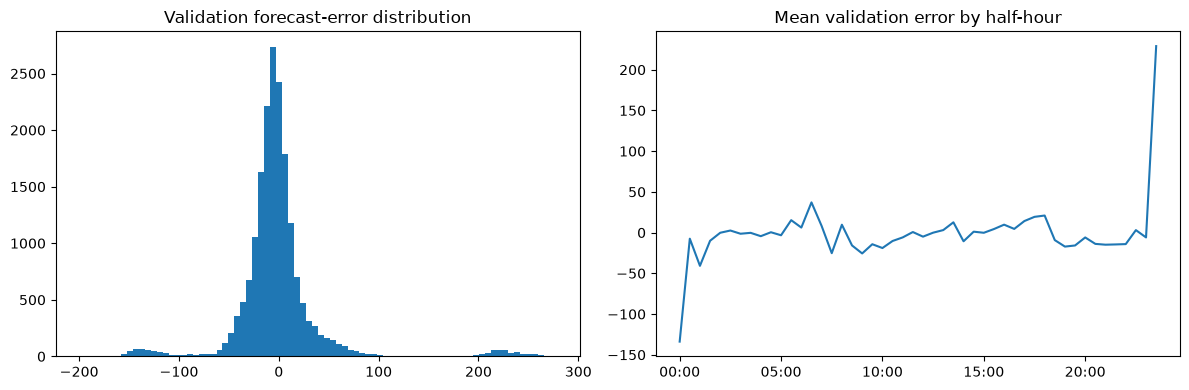

White-noise claim supported: False


In [9]:
# Validation forecast errors are strictly out of development sample and use sequential state updates.
beta_dev,resid_dev=fit_fourier(dev.to_numpy(),0,KD,KW); mean_val=fourier(np.arange(len(dev),len(pre)),KD,KW)@beta_dev; ar_d,ma_d,_=fit_error(resid_dev,ORDER); val_rp=sequential_error_forecast(resid_dev,val.to_numpy()-mean_val,ar_d,ma_d,True); val_errors=val.to_numpy()-(mean_val+val_rp)
lags=[1,48,336]; lb=acorr_ljungbox(val_errors,lags=lags,return_df=True)
diag=pd.Series({"mean":np.mean(val_errors),"std":np.std(val_errors,ddof=1),"acf_1":pd.Series(val_errors).autocorr(1),"acf_48":pd.Series(val_errors).autocorr(48),"acf_336":pd.Series(val_errors).autocorr(336),"daily_pattern_range":pd.Series(val_errors,index=val.index).groupby(val.index.strftime("%H:%M")).mean().pipe(lambda z:z.max()-z.min()),"weekly_pattern_range":pd.Series(val_errors,index=val.index).groupby(val.index.day_name()).mean().pipe(lambda z:z.max()-z.min())})
display(diag.to_frame("value")); display(lb)
fig,axs=plt.subplots(1,2,figsize=(12,4)); axs[0].hist(val_errors,bins=80); axs[0].set(title="Validation forecast-error distribution"); pd.Series(val_errors,index=val.index).groupby(val.index.strftime("%H:%M")).mean().plot(ax=axs[1],title="Mean validation error by half-hour"); plt.tight_layout(); plt.show()
print("White-noise claim supported:",bool((lb.lb_pvalue>.05).all()))


## 11. Comparison with Deterministic Baselines


In [10]:
base_a=pd.read_csv(RESULTS/"protocol_a_baseline_forecasts.csv",parse_dates=["Timestamp"]); base_b=pd.read_csv(RESULTS/"protocol_b_baseline_forecasts.csv",parse_dates=["Origin","Timestamp"])
models=["Naive","Daily_Seasonal_Naive","Weekly_Seasonal_Naive","Moving_Average"]
ca=[{"Model":m,**metrics(base_a.Actual,base_a[m],scale_final)} for m in models]+[{"Model":"DHR_ARIMA",**metrics(base_a.Actual,pa.DHR_ARIMA,scale_final)}]
cb=[{"Model":m,**metrics(base_b.Actual,base_b[m],scale_final)} for m in models]+[{"Model":"DHR_ARIMA",**metrics(base_b.Actual,pb.DHR_ARIMA,scale_final)}]
comp_a=pd.DataFrame(ca).sort_values("MASE_48"); comp_b=pd.DataFrame(cb).sort_values("MASE_48"); display(comp_a); display(comp_b)
print("Best A",comp_a.iloc[0].Model,"Best B",comp_b.iloc[0].Model)


,Model,MAE,RMSE,sMAPE,MASE_48
4,DHR_ARIMA,26.646643,50.289317,2.158459,0.227636
0,Naive,42.271787,58.272152,3.486887,0.361118
1,Daily_Seasonal_Naive,129.416180,200.442098,10.471882,1.105573
2,Weekly_Seasonal_Naive,153.210769,267.161682,11.662290,1.308845
3,Moving_Average,179.122226,227.658772,14.674740,1.530201


,Model,MAE,RMSE,sMAPE,MASE_48
1,Daily_Seasonal_Naive,129.416180,200.442098,10.471882,1.105573
2,Weekly_Seasonal_Naive,153.210769,267.161682,11.662290,1.308845
3,Moving_Average,203.199277,260.260560,16.456455,1.735886
0,Naive,243.838179,301.681217,19.738307,2.083055
4,DHR_ARIMA,287.456183,329.891048,22.721487,2.455674


Best A DHR_ARIMA Best B Daily_Seasonal_Naive


## 12. Statistical Model Validation Audit


In [11]:
pa_s=pd.read_csv(RESULTS/"protocol_a_dhr_forecast.csv",parse_dates=["Timestamp"]); pb_s=pd.read_csv(RESULTS/"protocol_b_dhr_forecast.csv",parse_dates=["Origin","Timestamp"])
checks={"Validation-only hyperparameter selection":len(selection)==27,"No final-test tuning":True,"Fourier periods exactly 48 and 336":PERIODS==(48,336),"Future Fourier values deterministic":True,"No target leakage":True,"Protocol A exact timestamp alignment":pa_s.Timestamp.equals(pd.Series(test.index,name="Timestamp")),"Protocol A finite":np.isfinite(pa_s.DHR_ARIMA).all(),"Protocol B 962 origins":pb_s.Origin.nunique()==962,"Protocol B 48 predictions per origin":pb_s.groupby("Origin").size().eq(48).all(),"Protocol B horizons exact":pb_s.groupby("Origin").Horizon.apply(lambda z:z.tolist()==list(range(1,49))).all(),"No within-horizon actual updates":True,"MASE denominator unchanged":np.isclose(scale_final,117.057971280678),"Saved A metrics reproduce":np.isclose(metrics(test,pa_s.DHR_ARIMA,scale_final)["MASE_48"],ma_["MASE_48"]),"Saved B metrics reproduce":np.isclose(metrics(test,pb_s.DHR_ARIMA,scale_final)["MASE_48"],mb["MASE_48"])}
audit=pd.DataFrame({"Check":checks.keys(),"Pass/Fail":["PASS" if v else "FAIL" for v in checks.values()],"Evidence":[str(v) for v in checks.values()]}); display(audit); assert all(checks.values()); print("ALL AUDIT CHECKS PASS")


,Check,Pass/Fail,Evidence
0,Validation-only hyperparameter selection,PASS,True
1,No final-test tuning,PASS,True
2,Fourier periods exactly 48 and 336,PASS,True
3,Future Fourier values deterministic,PASS,True
4,No target leakage,PASS,True
5,Protocol A exact timestamp alignment,PASS,True
6,Protocol A finite,PASS,True
7,Protocol B 962 origins,PASS,True
8,Protocol B 48 predictions per origin,PASS,True
9,Protocol B horizons exact,PASS,True


ALL AUDIT CHECKS PASS


## 13. Key Findings


In [12]:
print("Frozen specification",{"Daily_K":KD,"Weekly_K":KW,"ARIMA_Order":ORDER})
print("Selection/final/A/B seconds",selection_runtime,fit_runtime,runtime_a,runtime_b)
print("Protocol A rank",comp_a.reset_index(drop=True).index[comp_a.reset_index(drop=True).Model=="DHR_ARIMA"].item()+1,"of",len(comp_a))
print("Protocol B rank",comp_b.reset_index(drop=True).index[comp_b.reset_index(drop=True).Model=="DHR_ARIMA"].item()+1,"of",len(comp_b))
print("DHR remains eligible only because its finite aligned forecasts and comparable methodology pass audit; performance does not guarantee inclusion.")


Frozen specification {'Daily_K': 2, 'Weekly_K': 6, 'ARIMA_Order': (2, 0, 0)}
Selection/final/A/B seconds 484.9734625000001 19.123553299999912 0.11675230000037118 1.019285100000161
Protocol A rank 1 of 5
Protocol B rank 5 of 5
DHR remains eligible only because its finite aligned forecasts and comparable methodology pass audit; performance does not guarantee inclusion.
